# 01 iris data에 SHAP 써보기
주어진 그래프들을 그대로 그려봅시다.
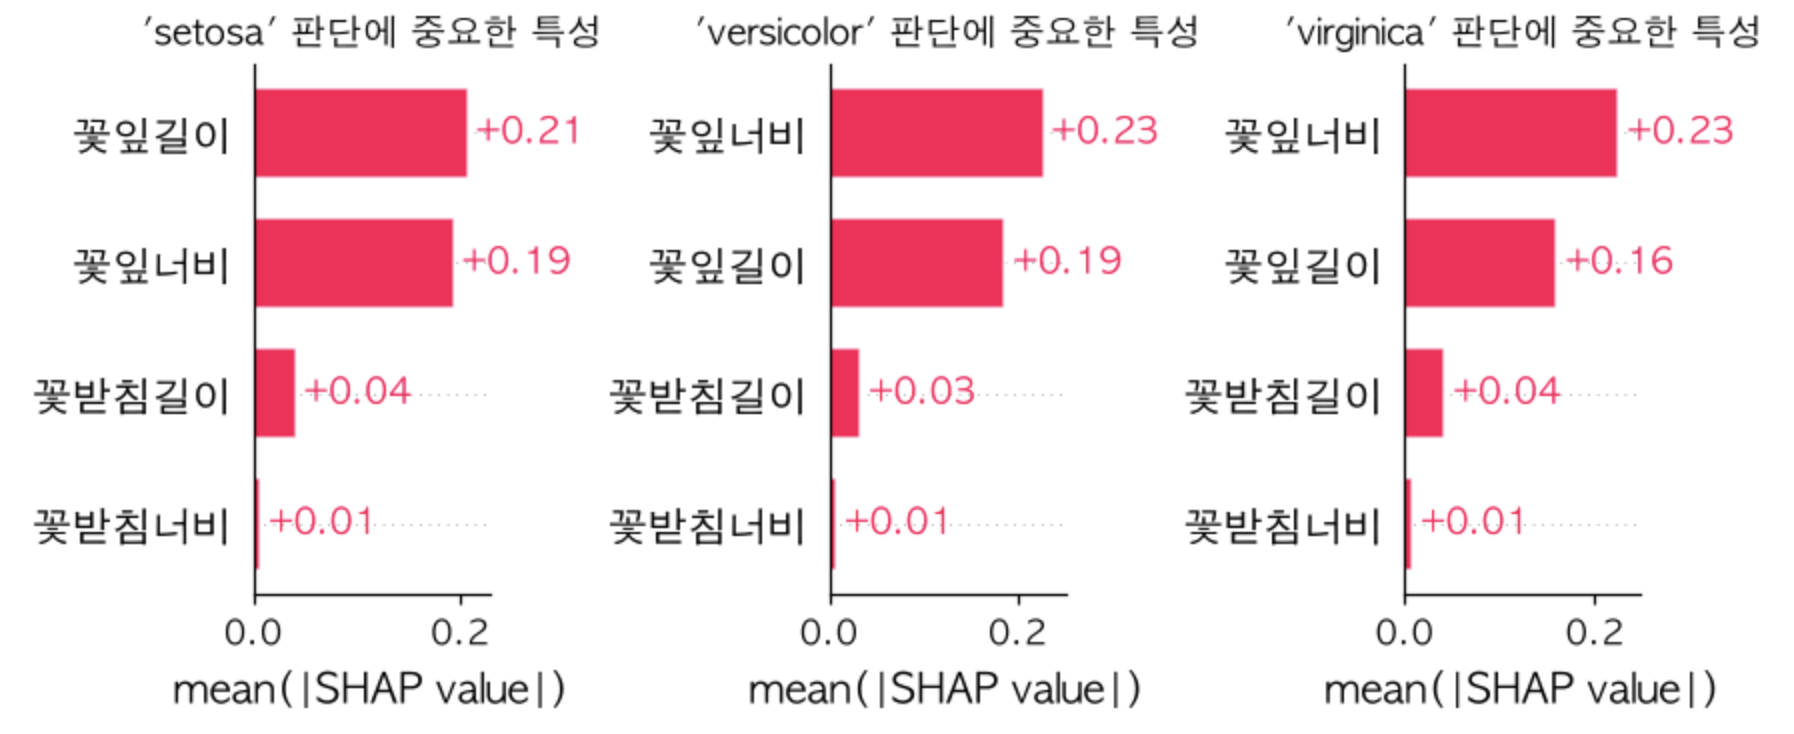

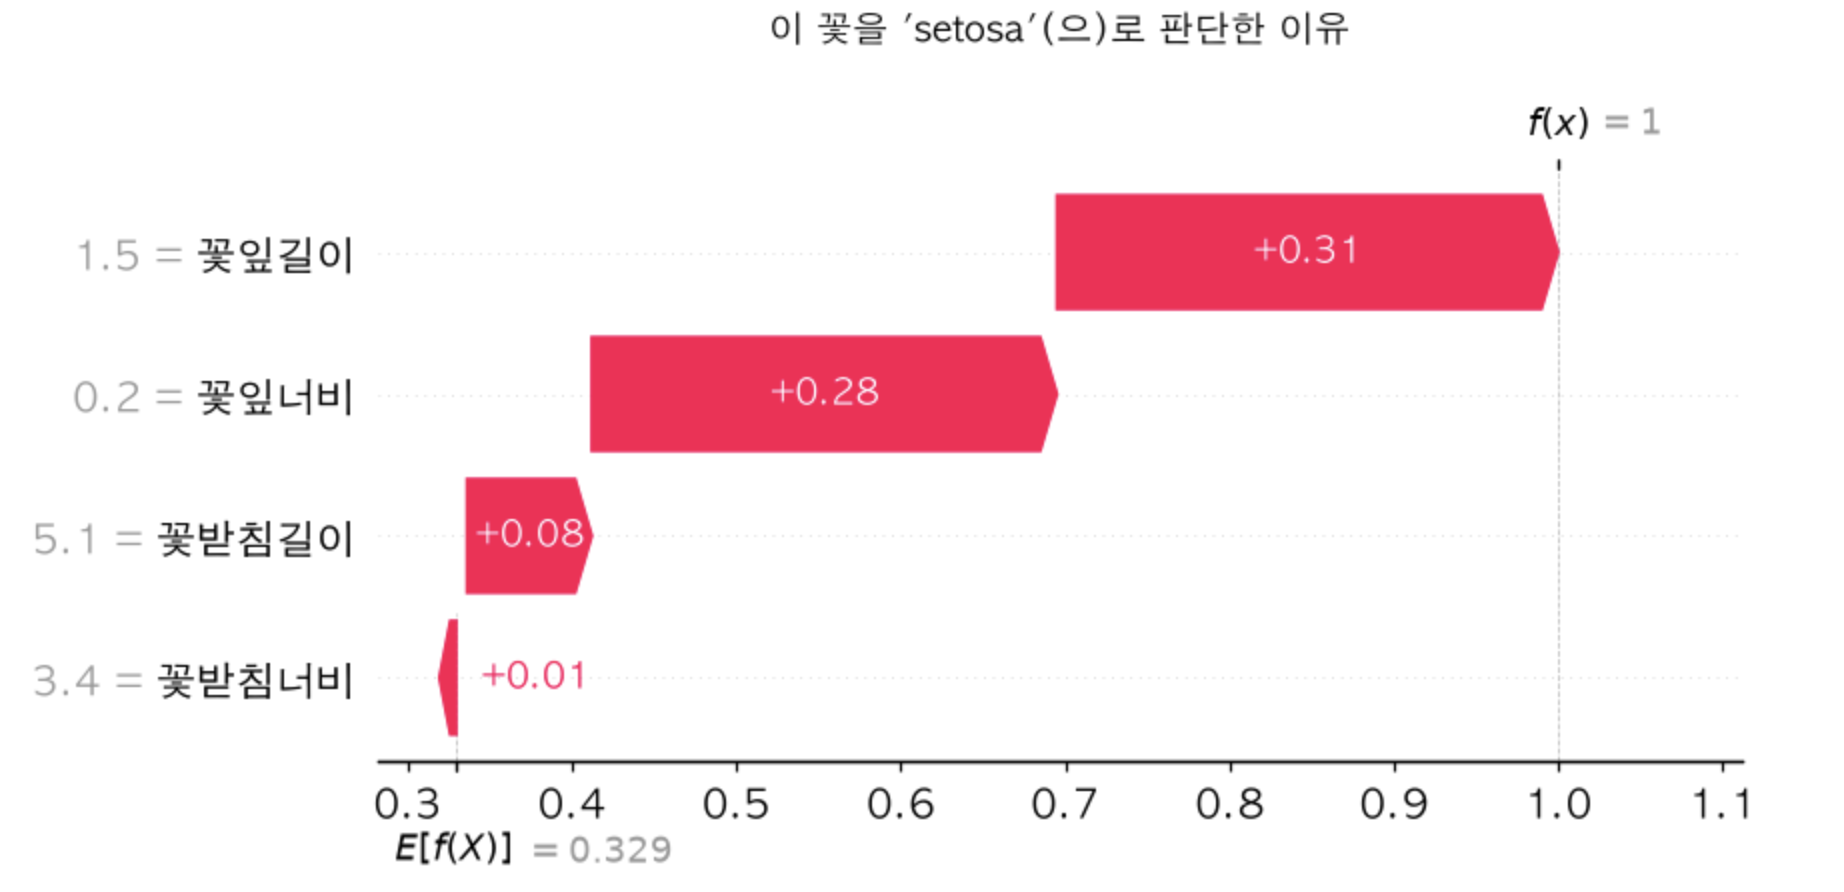
준이가 꼽는 꽃이 제가 꼽은 꽃이랑 다를 수 있어서 숫자는 약간 달라도 괜찮아요.

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

/Users/ethansul/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 시스템에 있는 한글 폰트를 자동으로 찾아 사용합니다.
korean_candidates = ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic",
                     "Malgun Gothic", "NanumBarunGothic", "Noto Sans CJK KR"]
installed = {f.name for f in font_manager.fontManager.ttflist}
picked = next((f for f in korean_candidates if f in installed), None)

if picked is None:
    # Colab 등에 한글 폰트가 없으면 나눔폰트를 설치해서 사용
    try:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "koreanize-matplotlib"])
        import koreanize_matplotlib  # noqa
        picked = "NanumGothic"
    except Exception:
        picked = "DejaVu Sans"  # 최후의 수단(한글은 깨질 수 있어요)

# 핵심: 한글 폰트를 1순위로, DejaVu Sans를 예비로 두면
#       SHAP 그래프의 '−'(마이너스) 기호까지 안 깨집니다.
plt.rcParams["font.family"] = [picked, "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
print("사용 폰트:", picked, "  한글 테스트 → 안녕하세요! 값: −1.5, +2.3")

사용 폰트: AppleGothic   한글 테스트 → 안녕하세요! 값: −1.5, +2.3


In [3]:
iris = load_iris()

In [4]:
features = iris['data']
feature_names = iris['feature_names']
label = iris['target']

In [5]:
df = pd.DataFrame(features, columns=feature_names)
df['target'] = label

In [6]:
X = df.iloc[:, :-1]

In [7]:
y = df.iloc[:, -1]

In [8]:
X = X.values

In [9]:
y = y.values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2026
)

In [11]:
# Random Forest
model = RandomForestClassifier(random_state=2026)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",2026
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap boots

In [12]:
# Accuracy
print(model.score(X_test, y_test))

0.9666666666666667


In [13]:
# SHAP
explainer = shap.TreeExplainer(model)

sv = explainer(X_test)

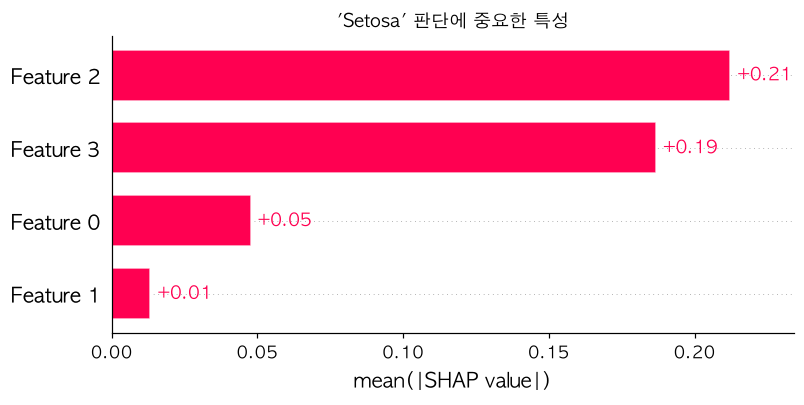

In [14]:
shap.plots.bar(sv[:, :, 0], show=False)

plt.title("'Setosa' 판단에 중요한 특성")

plt.show()

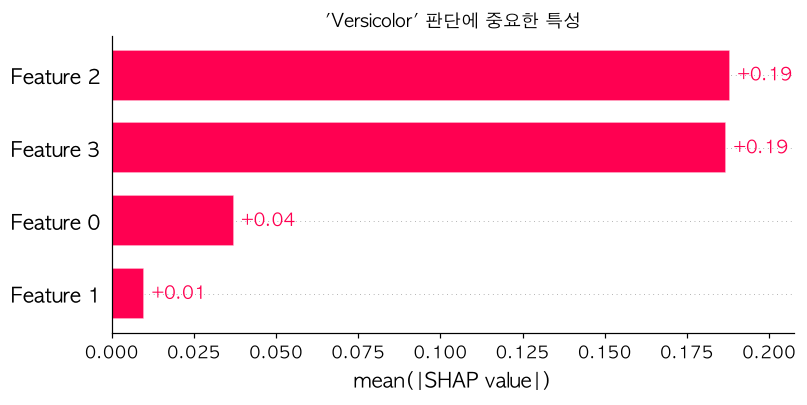

In [15]:
shap.plots.bar(sv[:, :, 1], show=False)

plt.title("'Versicolor' 판단에 중요한 특성")

plt.show()

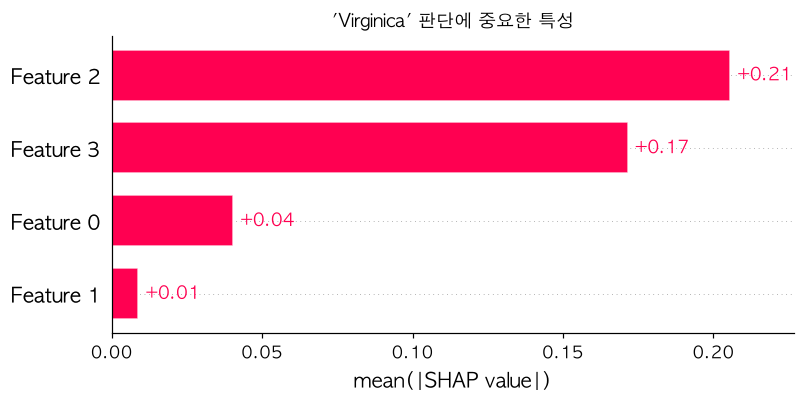

In [16]:
shap.plots.bar(sv[:, :, 2], show=False)

plt.title("'Virginica' 판단에 중요한 특성")

plt.show()

In [17]:
setosa_index = np.where(y_test == 0)[0][0]

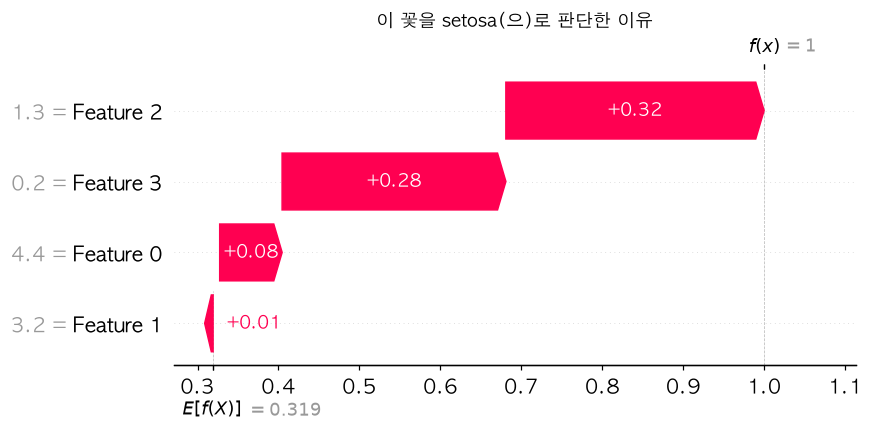

In [18]:
shap.plots.waterfall(sv[setosa_index, :, 0], show=False)

plt.title("이 꽃을 setosa(으)로 판단한 이유")

plt.show()